# LR Classifier on Raw Activations — Results Analysis

This notebook loads the outputs from `train_lr_classifier_streaming.py` and generates diagnostic plots across layers and granularities.

In [10]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc,
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

## 1 — Load all outputs

In [11]:
# === SET THIS TO YOUR OUTPUT DIRECTORY ===
OUTPUT_DIR = Path("/home/ines/Reasoning-activations/results/lr_classifier_layer18")

# JSON metrics
with open(OUTPUT_DIR / "lr_classifier_results.json") as f:
    results = json.load(f)

# Learned weight vectors
learned_weights = torch.load(OUTPUT_DIR / "lr_learned_weights.pt", weights_only=False)

# Per-layer diagnostics
diag_dir = OUTPUT_DIR / "diagnostics"
diagnostics = {}
for p in sorted(diag_dir.glob("layer_*_diagnostics.pt")):
    layer_key = p.stem.split("_")[1]
    diagnostics[layer_key] = torch.load(p, weights_only=False)

# Determine layers (exclude non-layer keys)
layer_keys = sorted([k for k in results if k.isdigit()], key=int)
granularities = [g for g in ["token", "step", "sample"]
                 if g in results[layer_keys[0]]]

print(f"Layers      : {layer_keys}")
print(f"Granularities: {granularities}")
print(f"Diagnostics  : {sorted(diagnostics.keys())}")


Layers      : ['18']
Granularities: ['token', 'step', 'sample']
Diagnostics  : ['18']


## 2 — Performance across layers (Accuracy / AUROC / F1)

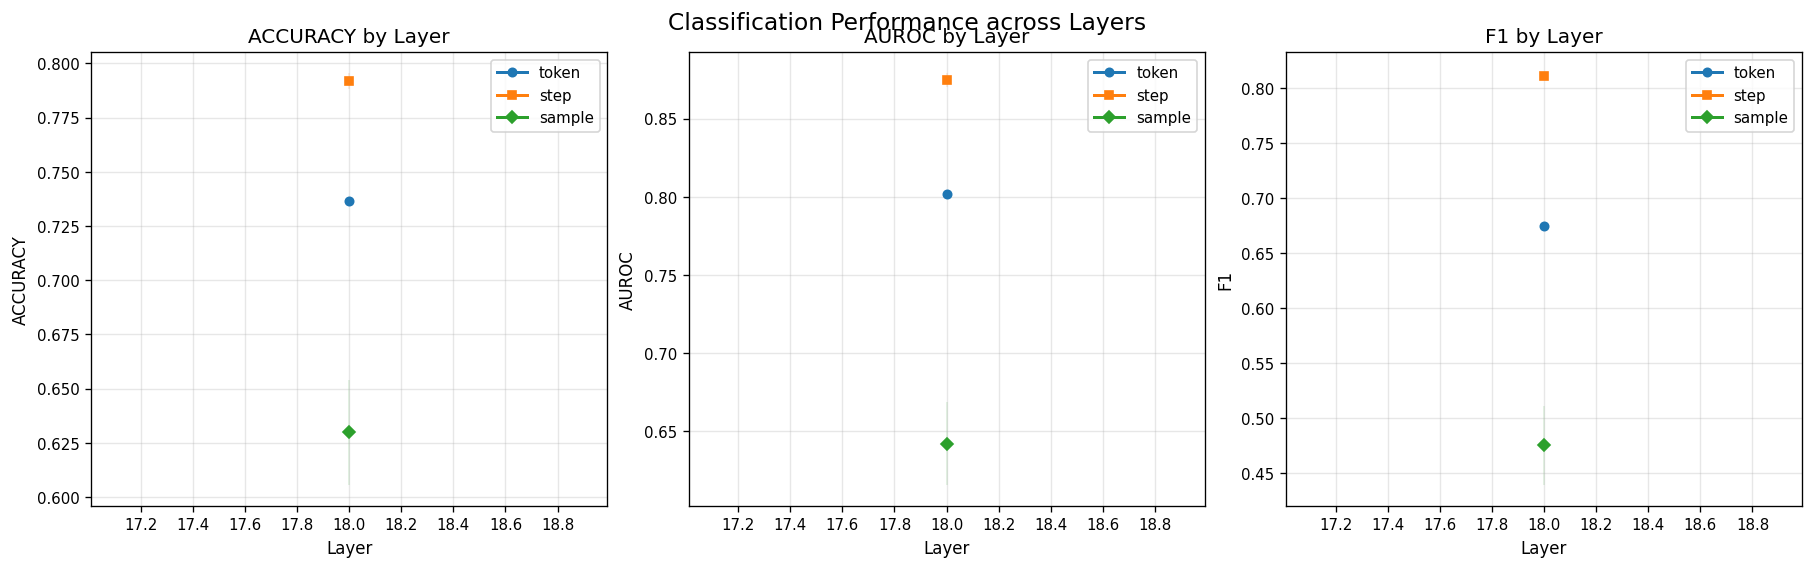

In [12]:
metric_map = {
    "token":  {"accuracy": "accuracy",  "auroc": "auroc",  "f1": "f1"},
    "step":   {"accuracy": "cv_accuracy_mean", "auroc": "cv_roc_auc_mean", "f1": "cv_f1_mean"},
    "sample": {"accuracy": "cv_accuracy_mean", "auroc": "cv_roc_auc_mean", "f1": "cv_f1_mean"},
}
std_map = {
    "step":   {"accuracy": "cv_accuracy_std", "auroc": "cv_roc_auc_std", "f1": "cv_f1_std"},
    "sample": {"accuracy": "cv_accuracy_std", "auroc": "cv_roc_auc_std", "f1": "cv_f1_std"},
}

layers_int = [int(l) for l in layer_keys]
colors = {"token": "#1f77b4", "step": "#ff7f0e", "sample": "#2ca02c"}
markers = {"token": "o", "step": "s", "sample": "D"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric_name in zip(axes, ["accuracy", "auroc", "f1"]):
    for gran in granularities:
        vals, stds = [], []
        for lk in layer_keys:
            m = results[lk].get(gran, {})
            key = metric_map[gran][metric_name]
            vals.append(m.get(key, np.nan))
            if gran in std_map:
                stds.append(m.get(std_map[gran][metric_name], 0))
            else:
                stds.append(0)
        vals, stds = np.array(vals), np.array(stds)
        ax.plot(layers_int, vals, marker=markers[gran], label=gran,
                color=colors[gran], linewidth=1.8, markersize=5)
        if stds.any():
            ax.fill_between(layers_int, vals - stds, vals + stds,
                            alpha=0.15, color=colors[gran])
    ax.set_xlabel("Layer")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(metric_name.upper() + " by Layer")
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)

fig.suptitle("Classification Performance across Layers", fontsize=14, y=1.02)
plt.show()

## 3 — Token-level ROC & Precision-Recall curves

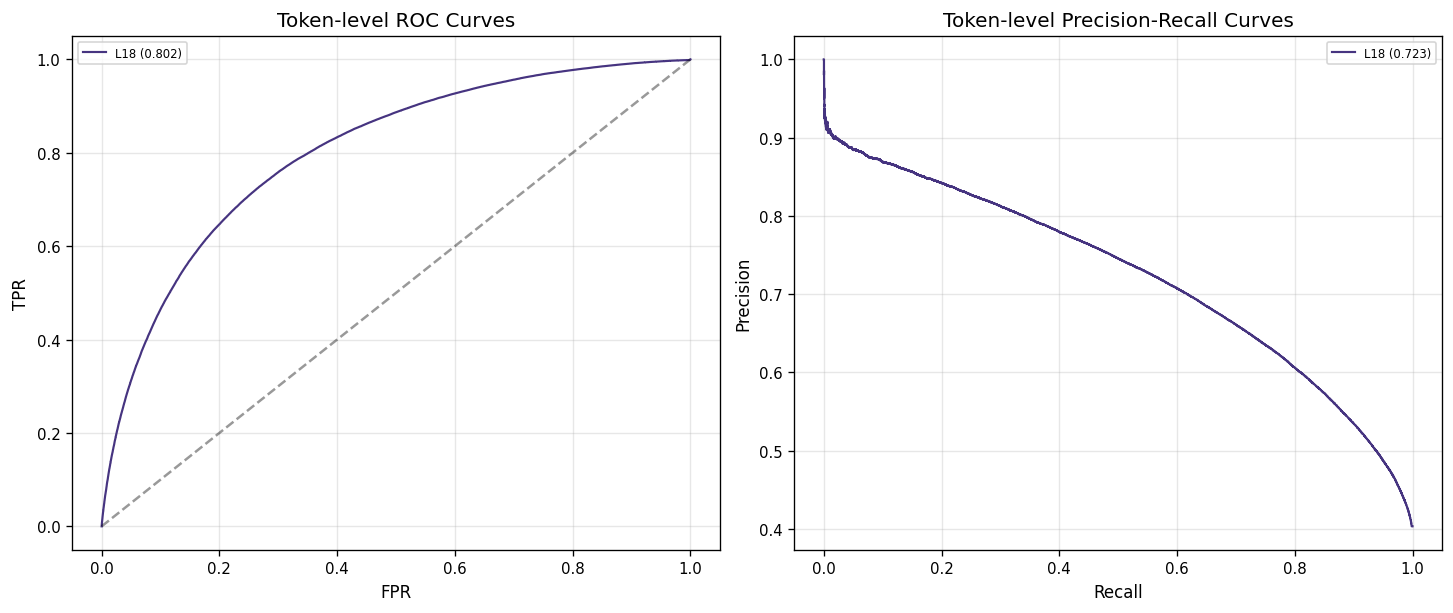

In [13]:
if "token" in granularities:
    cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(layer_keys)))

    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

    for idx, lk in enumerate(layer_keys):
        diag = diagnostics.get(lk, {}).get("token")
        if diag is None:
            continue
        y_true = np.asarray(diag["y_true"])
        y_prob = np.asarray(diag["y_prob"])

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc_val = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=cmap[idx], linewidth=1.3,
                    label=f"L{lk} ({roc_auc_val:.3f})")

        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        pr_auc_val = auc(rec, prec)
        ax_pr.plot(rec, prec, color=cmap[idx], linewidth=1.3,
                   label=f"L{lk} ({pr_auc_val:.3f})")

    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax_roc.set(xlabel="FPR", ylabel="TPR", title="Token-level ROC Curves")
    ax_roc.legend(fontsize=7, ncol=2)
    ax_roc.grid(True, alpha=0.3)

    ax_pr.set(xlabel="Recall", ylabel="Precision", title="Token-level Precision-Recall Curves")
    ax_pr.legend(fontsize=7, ncol=2)
    ax_pr.grid(True, alpha=0.3)
    plt.show()
else:
    print("Token granularity not available — skipping ROC/PR curves.")

## 4 — Token-level confusion matrix (best layer by AUROC)

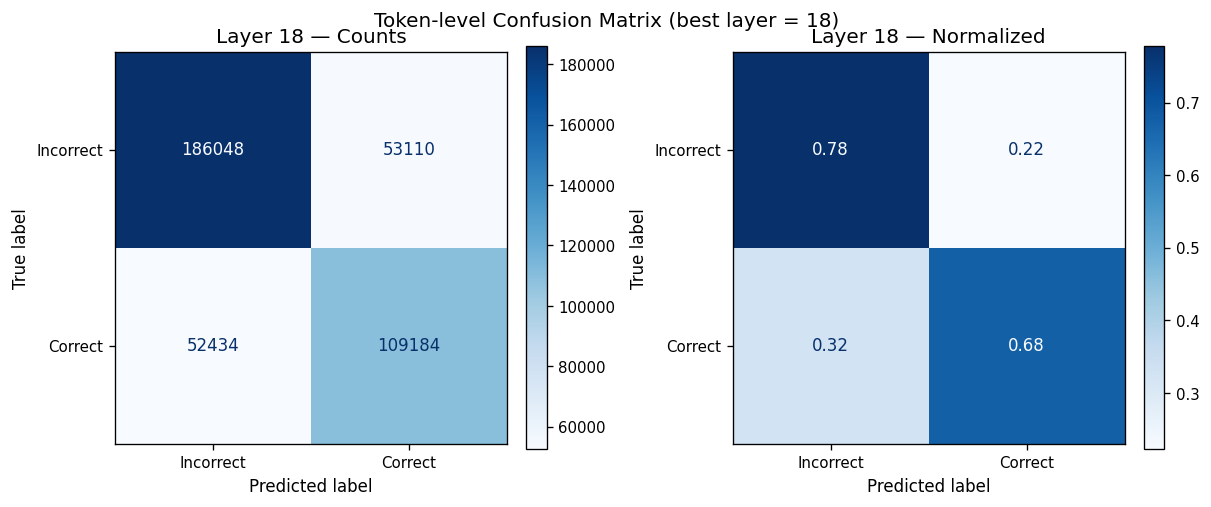

In [14]:
if "token" in granularities:
    best_layer = max(layer_keys,
                     key=lambda lk: results[lk]["token"].get("auroc", 0))
    diag = diagnostics[best_layer]["token"]
    y_true = np.asarray(diag["y_true"])
    y_pred = np.asarray(diag["y_pred"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for ax, norm, title in [(ax1, None, "Counts"), (ax2, "true", "Normalized")]:
        cm = confusion_matrix(y_true, y_pred, normalize=norm)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Incorrect", "Correct"])
        disp.plot(ax=ax, cmap="Blues", values_format=".0f" if norm is None else ".2f")
        ax.set_title(f"Layer {best_layer} — {title}")
    fig.suptitle(f"Token-level Confusion Matrix (best layer = {best_layer})",
                 fontsize=12, y=1.02)
    plt.show()

## 5 — CV fold variance (step & sample level)

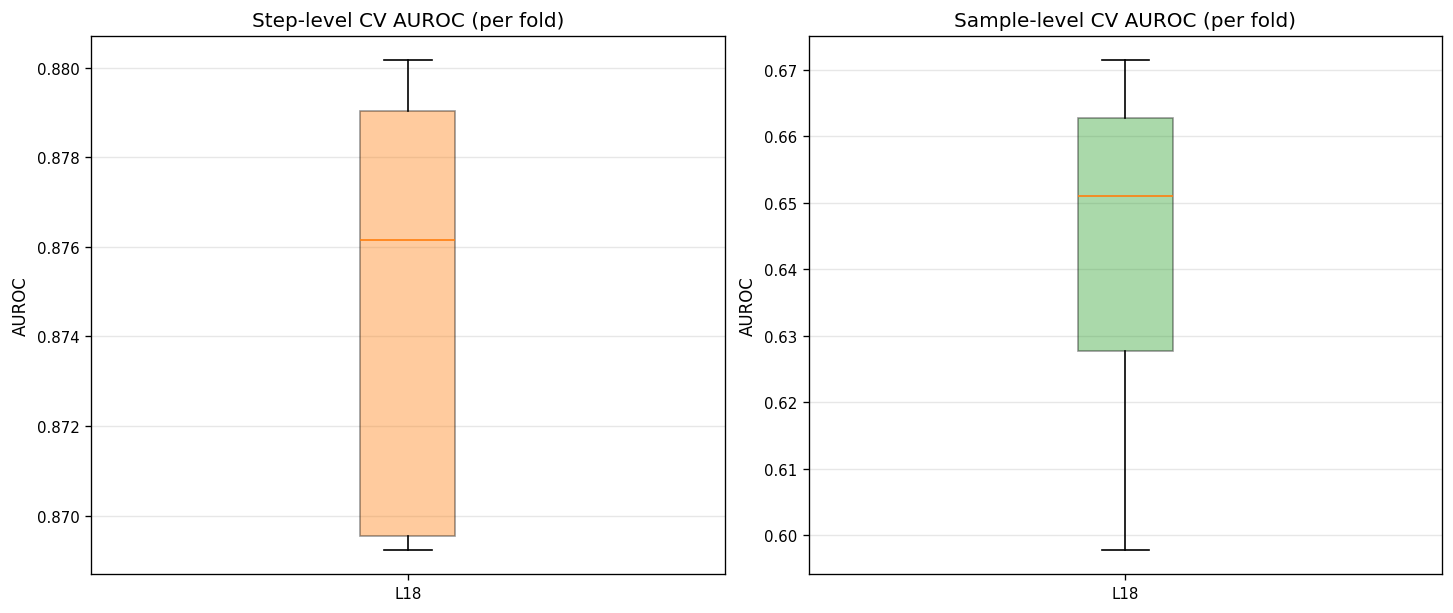

In [15]:
cv_grans = [g for g in ["step", "sample"] if g in granularities]

if cv_grans:
    fig, axes = plt.subplots(1, len(cv_grans), figsize=(6 * len(cv_grans), 5))
    if len(cv_grans) == 1:
        axes = [axes]

    for ax, gran in zip(axes, cv_grans):
        fold_data = []
        tick_labels = []
        for lk in layer_keys:
            folds = results[lk].get(gran, {}).get("cv_roc_auc_folds")
            if folds is not None:
                fold_data.append(folds)
                tick_labels.append(f"L{lk}")
        if fold_data:
            bp = ax.boxplot(fold_data, labels=tick_labels, patch_artist=True,
                            boxprops=dict(facecolor=colors[gran], alpha=0.4))
            ax.set_ylabel("AUROC")
            ax.set_title(f"{gran.capitalize()}-level CV AUROC (per fold)")
            ax.grid(True, alpha=0.3, axis='y')
    plt.show()
else:
    print("No CV granularities available.")

## 6 — Train vs Test performance (overfitting diagnostic)

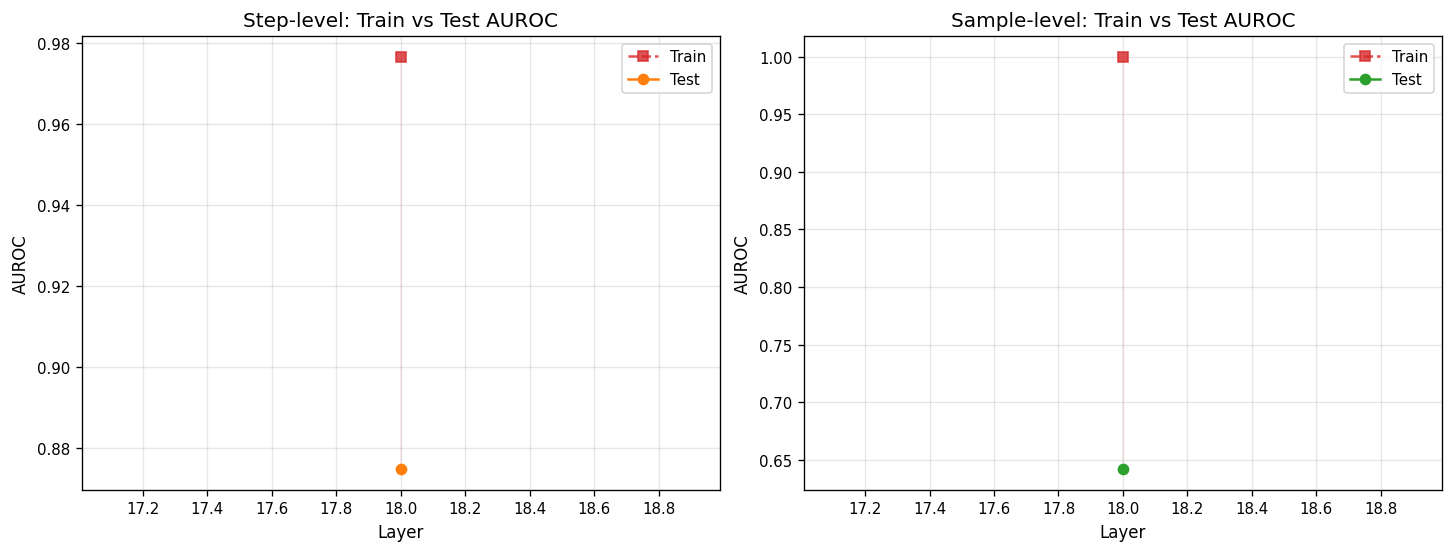

In [16]:
if cv_grans:
    fig, axes = plt.subplots(1, len(cv_grans), figsize=(6 * len(cv_grans), 4.5))
    if len(cv_grans) == 1:
        axes = [axes]

    for ax, gran in zip(axes, cv_grans):
        train_vals, test_vals = [], []
        for lk in layer_keys:
            m = results[lk].get(gran, {})
            train_vals.append(m.get("cv_roc_auc_train_mean", np.nan))
            test_vals.append(m.get("cv_roc_auc_mean", np.nan))
        ax.plot(layers_int, train_vals, 's--', label="Train", color="#d62728", alpha=0.8)
        ax.plot(layers_int, test_vals, 'o-', label="Test", color=colors[gran])
        ax.fill_between(layers_int, test_vals, train_vals, alpha=0.1, color="#d62728")
        ax.set_xlabel("Layer")
        ax.set_ylabel("AUROC")
        ax.set_title(f"{gran.capitalize()}-level: Train vs Test AUROC")
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3)
    plt.show()

## 7 — LR weights vs reasoning directions (cosine similarity)

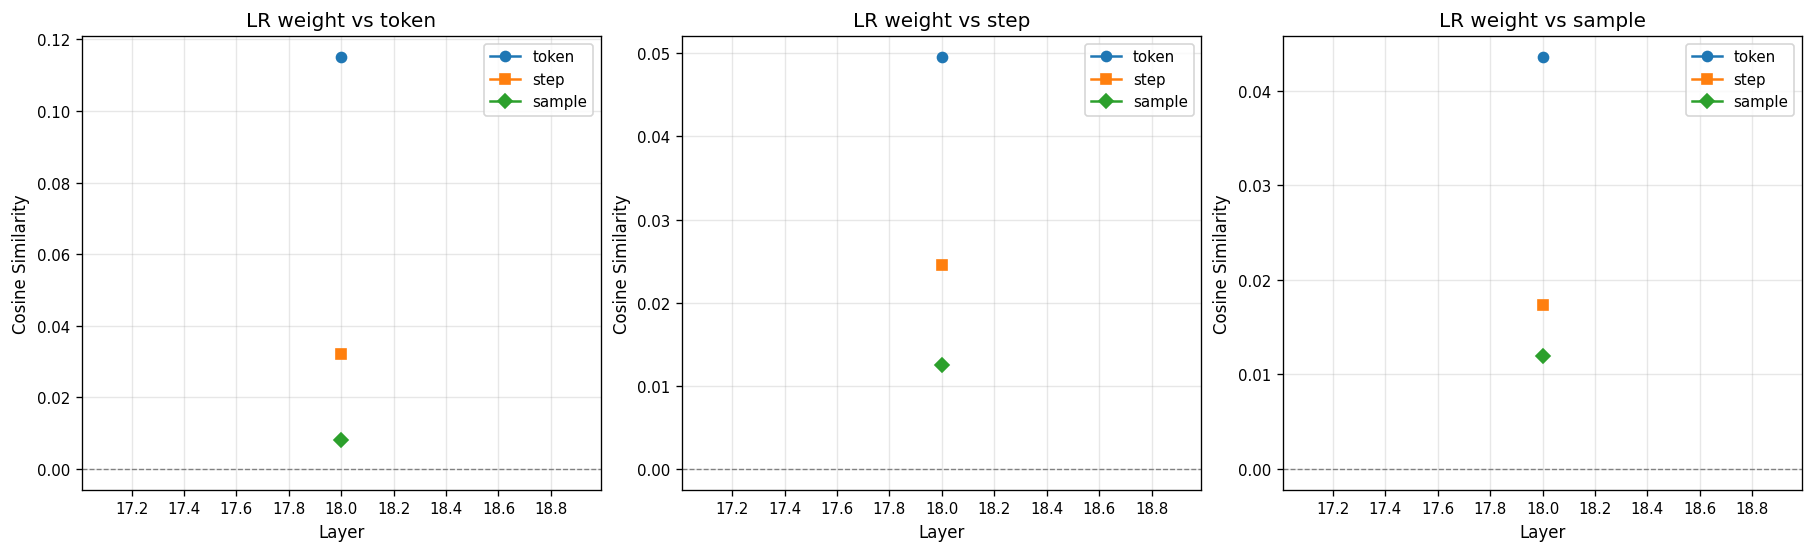

In [17]:
# Collect all reasoning-direction comparison data
cosine_data = {}  # {direction_name: {gran: [val_per_layer]}}

for gran in granularities:
    for lk in layer_keys:
        comps = results[lk].get(gran, {}).get("weight_vs_reasoning_vectors", {})
        for dname, cval in comps.items():
            cosine_data.setdefault(dname, {}).setdefault(gran, []).append(cval)

if cosine_data:
    n_dirs = len(cosine_data)
    fig, axes = plt.subplots(1, min(n_dirs, 4), figsize=(5 * min(n_dirs, 4), 4.5),
                             squeeze=False)
    axes = axes.ravel()

    for ax, (dname, gran_vals) in zip(axes, list(cosine_data.items())[:4]):
        for gran, vals in gran_vals.items():
            ax.plot(layers_int[:len(vals)], vals, marker=markers[gran],
                    color=colors[gran], label=gran, linewidth=1.5)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
        ax.set_xlabel("Layer")
        ax.set_ylabel("Cosine Similarity")
        short_name = dname.replace('reasoning_direction_', '').replace('reasoning_direction', 'RD')
        ax.set_title(f"LR weight vs {short_name}")
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3)

    for ax in axes[len(cosine_data):]:
        ax.set_visible(False)
    plt.show()
else:
    print("No reasoning-direction comparisons found in results.")

## 8 — Cross-granularity weight similarity heatmap

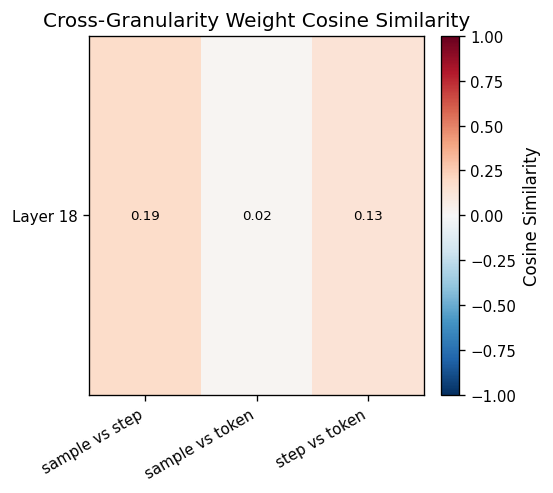

In [18]:
cross_sims = results.get("cross_weight_similarities", {})

# Per-layer cross-granularity
per_layer_sims = {lk: cross_sims.get(lk, {}) for lk in layer_keys if lk in cross_sims}

if per_layer_sims:
    pair_names = sorted(set(p for d in per_layer_sims.values() for p in d))
    matrix = np.full((len(layer_keys), len(pair_names)), np.nan)
    for i, lk in enumerate(layer_keys):
        for j, pn in enumerate(pair_names):
            matrix[i, j] = per_layer_sims.get(lk, {}).get(pn, np.nan)

    fig, ax = plt.subplots(figsize=(max(4, len(pair_names) * 1.5), max(4, len(layer_keys) * 0.45)))
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(pair_names)))
    ax.set_xticklabels([p.replace('_vs_', ' vs ') for p in pair_names], rotation=30, ha='right')
    ax.set_yticks(range(len(layer_keys)))
    ax.set_yticklabels([f"Layer {l}" for l in layer_keys])
    plt.colorbar(im, ax=ax, label="Cosine Similarity")
    ax.set_title("Cross-Granularity Weight Cosine Similarity")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center', fontsize=8)
    plt.show()
else:
    print("No cross-granularity similarity data.")

## 9 — Cross-layer weight similarity (within each granularity)

In [19]:
cross_layer_keys = [k for k in cross_sims if k.startswith("cross_layer_")]

if cross_layer_keys:
    fig, axes = plt.subplots(1, len(cross_layer_keys),
                             figsize=(6 * len(cross_layer_keys), 5), squeeze=False)
    axes = axes.ravel()

    for ax, clk in zip(axes, sorted(cross_layer_keys)):
        pairs = cross_sims[clk]
        n = len(layer_keys)
        mat = np.eye(n)
        layer_to_idx = {l: i for i, l in enumerate(layer_keys)}

        for pair_name, cosval in pairs.items():
            # parse "layer18_vs_layer19"
            parts = pair_name.replace("layer", "").split("_vs_")
            if len(parts) == 2 and parts[0] in layer_to_idx and parts[1] in layer_to_idx:
                i, j = layer_to_idx[parts[0]], layer_to_idx[parts[1]]
                mat[i, j] = mat[j, i] = cosval

        im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(n))
        ax.set_xticklabels([f"L{l}" for l in layer_keys], rotation=45)
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"L{l}" for l in layer_keys])
        gran_name = clk.replace("cross_layer_", "")
        ax.set_title(f"Cross-Layer Similarity ({gran_name})")
        plt.colorbar(im, ax=ax, shrink=0.8)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', fontsize=6)
    plt.show()
else:
    print("No cross-layer similarity data (need ≥2 layers).")

No cross-layer similarity data (need ≥2 layers).


## 10 — Weight vector magnitude & sparsity across layers

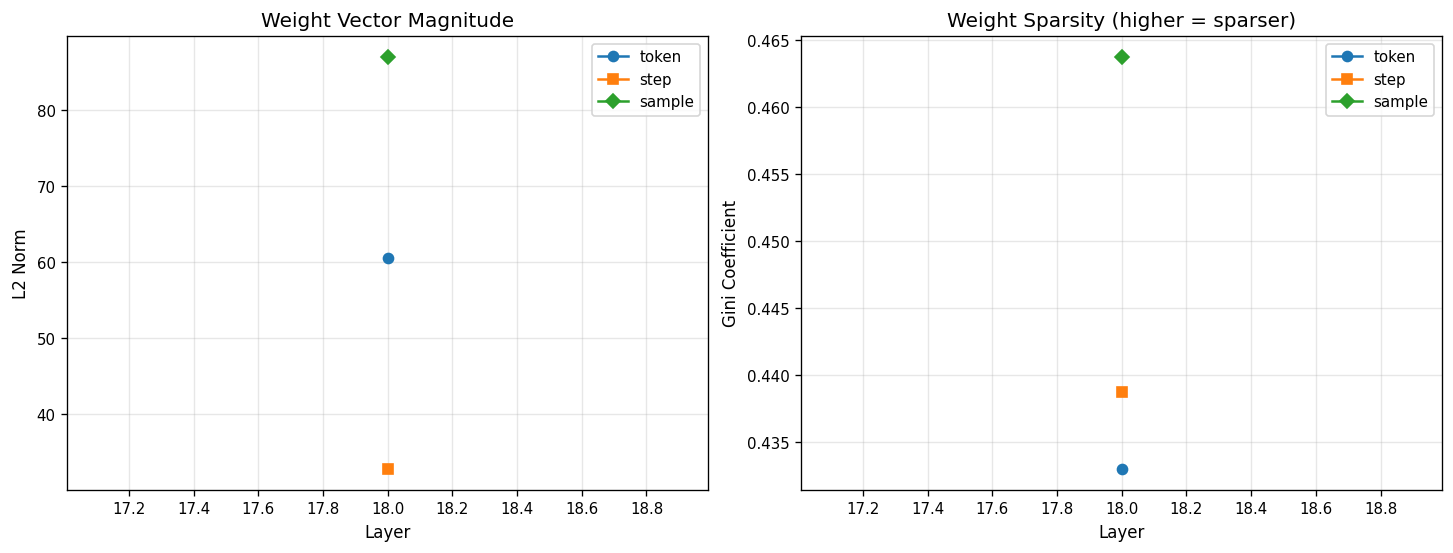

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for gran in granularities:
    norms, ginis = [], []
    for lk in layer_keys:
        w = learned_weights.get(lk, {}).get(gran)
        if w is None:
            norms.append(np.nan); ginis.append(np.nan)
            continue
        w_np = w.numpy()
        norms.append(float(np.linalg.norm(w_np)))
        # Gini coefficient as sparsity measure
        abs_w = np.sort(np.abs(w_np))
        n = len(abs_w)
        gini = (2 * np.sum((np.arange(1, n+1)) * abs_w) / (n * abs_w.sum()) - (n+1)/n) if abs_w.sum() > 0 else 0
        ginis.append(gini)

    ax1.plot(layers_int, norms, marker=markers[gran], color=colors[gran],
             label=gran, linewidth=1.5)
    ax2.plot(layers_int, ginis, marker=markers[gran], color=colors[gran],
             label=gran, linewidth=1.5)

ax1.set(xlabel="Layer", ylabel="L2 Norm", title="Weight Vector Magnitude")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2.set(xlabel="Layer", ylabel="Gini Coefficient", title="Weight Sparsity (higher = sparser)")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

## 11 — Top-k feature weights (best layer)

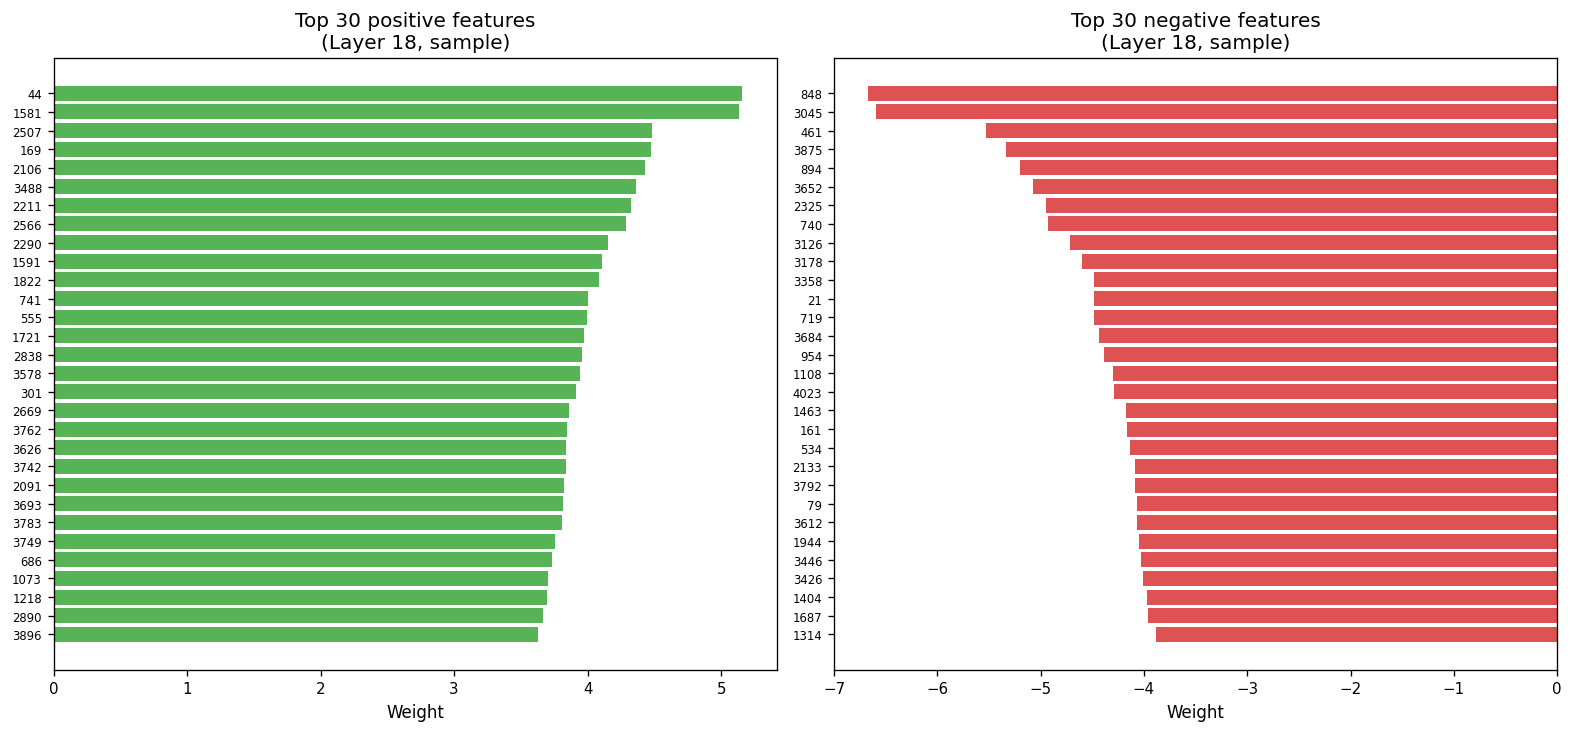

In [21]:
TOP_K = 30

# Pick best layer by sample-level AUROC if available, else step, else token
best_gran = "sample" if "sample" in granularities else ("step" if "step" in granularities else "token")
if best_gran == "token":
    best_lk = max(layer_keys, key=lambda lk: results[lk]["token"].get("auroc", 0))
else:
    best_lk = max(layer_keys, key=lambda lk: results[lk][best_gran].get("cv_roc_auc_mean", 0))

w = learned_weights[best_lk][best_gran].numpy()
top_pos = np.argsort(w)[-TOP_K:][::-1]
top_neg = np.argsort(w)[:TOP_K]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.barh(range(TOP_K), w[top_pos][::-1], color='#2ca02c', alpha=0.8)
ax1.set_yticks(range(TOP_K))
ax1.set_yticklabels([str(d) for d in top_pos[::-1]], fontsize=7)
ax1.set_xlabel("Weight")
ax1.set_title(f"Top {TOP_K} positive features\n(Layer {best_lk}, {best_gran})")

ax2.barh(range(TOP_K), w[top_neg][::-1], color='#d62728', alpha=0.8)
ax2.set_yticks(range(TOP_K))
ax2.set_yticklabels([str(d) for d in top_neg[::-1]], fontsize=7)
ax2.set_xlabel("Weight")
ax2.set_title(f"Top {TOP_K} negative features\n(Layer {best_lk}, {best_gran})")
plt.show()

## 12 — Weight distribution histogram (best layer, all granularities)

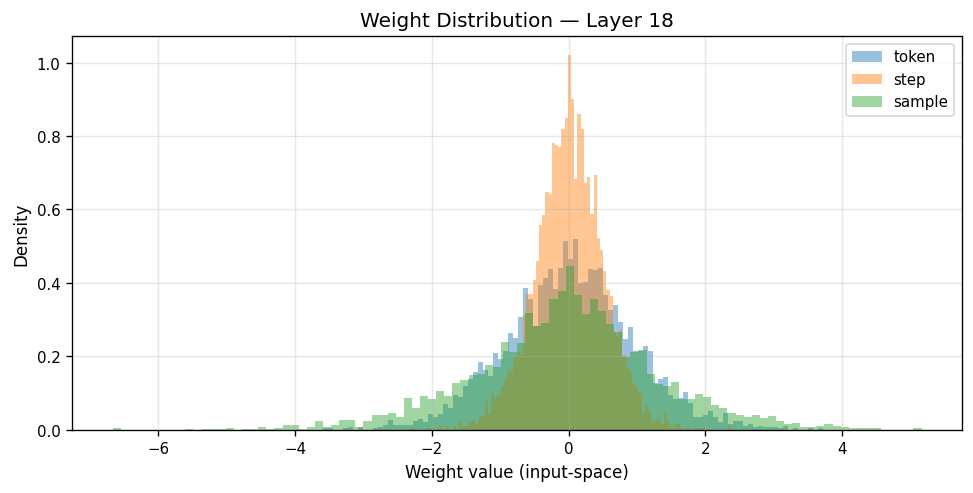

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

for gran in granularities:
    w = learned_weights.get(best_lk, {}).get(gran)
    if w is not None:
        ax.hist(w.numpy(), bins=100, alpha=0.45, label=gran, color=colors[gran],
                density=True)

ax.set_xlabel("Weight value (input-space)")
ax.set_ylabel("Density")
ax.set_title(f"Weight Distribution — Layer {best_lk}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 13 — Convergence & timing diagnostics

In [23]:
if cv_grans:
    print(f"{'Layer':<8} {'Gran':<8} {'n_iter':<8} {'max_iter':<10} {'fit_time (s)':<14} {'score_time (s)'}")
    print("-" * 65)
    for lk in layer_keys:
        for gran in cv_grans:
            m = results[lk].get(gran, {})
            n_it = m.get("n_iter", "?")
            mx_it = m.get("max_iter", "?")
            ft = m.get("cv_fit_time_mean", 0)
            st = m.get("cv_score_time_mean", 0)
            flag = "  ⚠️ CONVERGE" if isinstance(n_it, int) and isinstance(mx_it, int) and n_it >= mx_it else ""
            print(f"{lk:<8} {gran:<8} {str(n_it):<8} {str(mx_it):<10} {ft:<14.3f} {st:.3f}{flag}")

Layer    Gran     n_iter   max_iter   fit_time (s)   score_time (s)
-----------------------------------------------------------------
18       step     369      2000       28.782         0.315
18       sample   186      2000       7.290          0.118


## 14 — Summary table

In [24]:
print(f"{'Layer':<8}", end="")
for gran in granularities:
    print(f"{'| ' + gran + ' ACC':<16}{'AUROC':<10}{'F1':<10}", end="")
print()
print("-" * (8 + 36 * len(granularities)))

for lk in layer_keys:
    print(f"{lk:<8}", end="")
    for gran in granularities:
        m = results[lk].get(gran, {})
        if gran == "token":
            acc = m.get("accuracy", np.nan)
            aur = m.get("auroc", np.nan)
            f1  = m.get("f1", np.nan)
        else:
            acc = m.get("cv_accuracy_mean", np.nan)
            aur = m.get("cv_roc_auc_mean", np.nan)
            f1  = m.get("cv_f1_mean", np.nan)
        print(f"| {acc:<14.4f}{aur:<10.4f}{f1:<10.4f}", end="")
    print()

Layer   | token ACC     AUROC     F1        | step ACC      AUROC     F1        | sample ACC    AUROC     F1        
--------------------------------------------------------------------------------------------------------------------
18      | 0.7367        0.8019    0.6742    | 0.7919        0.8748    0.8111    | 0.6298        0.6421    0.4750    
